**1. Import Libraries**

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

**2. Data Collection**

In [9]:
df = pd.read_csv("/content/IMDB Dataset.csv")
df.shape

(50000, 2)

**3. Data Understanding**

In [8]:
# Let us display the first 5 columns of the datset
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [10]:
# Let us display the basic information of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [11]:
# Checking Missing values
df.isnull().sum()

,0
review,0
sentiment,0


In [13]:
# Checking duplicate records
df.duplicated().sum()


np.int64(418)

In [14]:
# Drop the duplicate records
df = df.drop_duplicates()

**Observations :**

- The dataset contains **50,000** movie reviews with 2 columns — **review** and **sentiment**.
- The dataset is free from missing values.
- The Dataset contains **418** duplicate records.The  Duplicate records are removed before model training to prevent repeated reviews from affecting the model.

In [17]:
# Let us check unique values
df['sentiment'].unique()

array(['positive', 'negative'], dtype=object)

**Observation :**
- The dataset contains two unique values **Positive** and **Negative.**

In [18]:
# Check class imabalance
df['sentiment'].value_counts()

,count
sentiment,
positive,24884
negative,24698


**Observation :**
- The dataset has almost equal numbers of **Positive** and **negative** reviews. Therefore, the dataset is** balanced**, and no class balancing technique is required.

**Text Analysis**

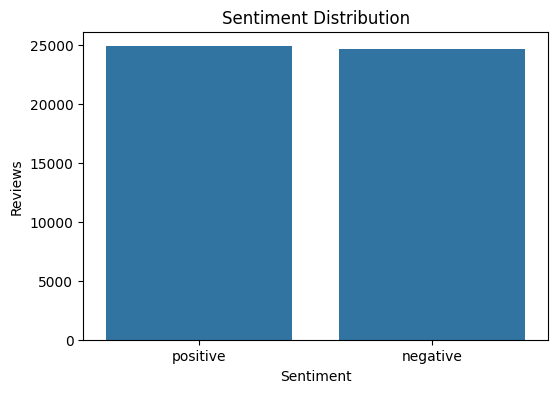

In [23]:
# Sentiment distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='sentiment')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Reviews")
plt.show()

**Observation :**
- The Dataset contains two sentiment classess , Positive and Negative.The Distribution of the classess is **balanced**,which is benefial for training classification models.

**4. Text Feature Engineering**

In [19]:
# Let us count how many words are present in each review (Number of words).
df['word_count'] = df['review'].apply(lambda x: len(x.split()))

/tmp/ipykernel_901/1814381480.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['word_count'] = df['review'].apply(lambda x: len(x.split()))


In [21]:
# Character count
df['char_count'] = df['review'].apply(lambda x: len(x))

/tmp/ipykernel_901/62956598.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['char_count'] = df['review'].apply(lambda x: len(x))


In [28]:
# Minimum and maximum character length
print("Minimum character Length :",df['char_count'].min())
print("Maximum character Length :", df['char_count'].max())

Minimum Word Length : 32
Maximum Word Length : 13704


In [29]:
# Minimum and maximum word length
print("Minimum word length : ", df['word_count'].min())
print("Maximum Word Length:", df['word_count'].max())

Minimum word length :  4
Maximum Word Length: 2470


In [24]:
# Word Frequency
from collections import Counter

word_freq = Counter(" ".join(df['review']).split())

word_freq.most_common(20)


[('the', 564474),
 ('a', 304819),
 ('and', 299760),
 ('of', 281597),
 ('to', 259895),
 ('is', 201675),
 ('in', 168738),
 ('I', 131363),
 ('that', 125878),
 ('this', 112817),
 ('it', 107118),
 ('/><br', 100211),
 ('was', 91903),
 ('as', 82521),
 ('with', 81950),
 ('for', 80317),
 ('The', 66714),
 ('but', 65796),
 ('on', 60726),
 ('movie', 60288)]

**5. Word Cloud**

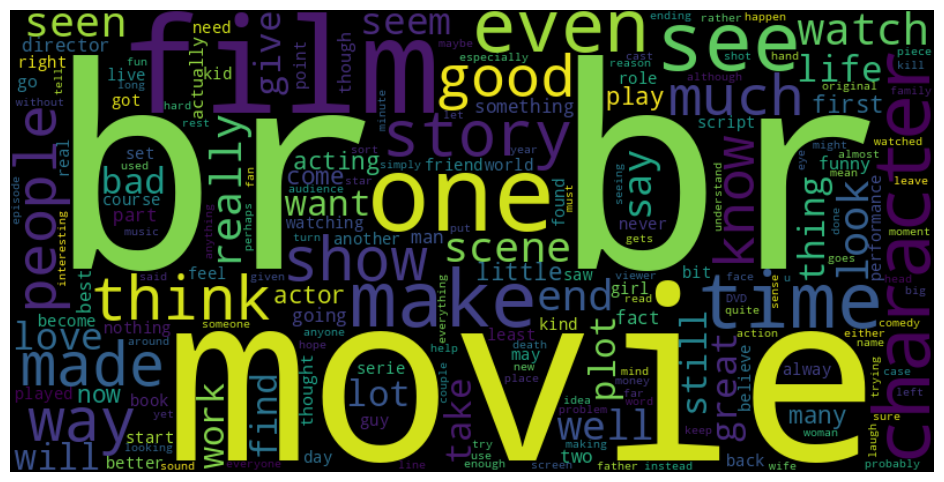

In [31]:
from wordcloud import WordCloud
text = " ".join(df['review'].astype(str))
wordcloud = WordCloud(width=800, height=400).generate(text)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

**Observation :**
- The word cloud shows the most frequently used words in the IMDB movie reviews. Words that appear larger in the word cloud occur more frequently in the dataset. It helps us understand the common words and overall content of the reviews.

**6. Text Preprocessing**

In [37]:
import re
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [38]:
def clean(doc):  # doc is a string of text

  # Let us define a regex to match special characters and digits
  regex = "[^a-zA-Z]"
  doc = re.sub(regex," ",doc)

  # Convert to lowercase
  doc = doc.lower()

  # Tokenization
  tokens = nltk.word_tokenize(doc)

  # Stopword Removal
  stop_words = set(stopwords.words('english'))
  negation_words = {'not','no','never','nor'}
  stop_words = stop_words - negation_words
  filtered_tokens = [word for word in tokens if word not in stop_words]

  # Lemmatize
  lemmatizer = WordNetLemmatizer()
  lemmatized_tokens = [lemmatizer.lemmatize(token) for token in filtered_tokens]

  # Join and return
  return " ".join(lemmatized_tokens)

In [39]:
df['clean_review'] = df['review'].apply(lambda x: clean(x))

**7. Input-Output Separation**

In [41]:
y = df['sentiment']
X = df['clean_review']

print(X.shape)
print(y.shape)

(49582,)
(49582,)


**8. Train-Test Split**

In [42]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size = 0.2,
                                                    random_state = 42,
                                                    stratify = y)

# Print shape of the train_test_split
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(39665,)
(9917,)
(39665,)
(9917,)


**9. Text Vectorization**

**TF - IDF**

In [49]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

**10. Baseline Model Building**

**Logistic Regression**

In [53]:
# Model building
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train_vec,y_train)

LogisticRegression()

In [54]:
# Prediction
y_pred = model.predict(X_test_vec)

In [55]:
# Model Evaluation
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred))

0.8946253907431683


In [56]:
# Classification report
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

    negative       0.91      0.88      0.89      4940
    positive       0.88      0.91      0.90      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



**Decision Tree**

In [74]:
# Model Building
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train_vec,y_train)

DecisionTreeClassifier()

In [ ]:
y_pred = dt_model.predict(X_test_vec)
accuracy_score(y_test,y_pred)

**Random Forest**

In [65]:
# Model Building
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train_vec,y_train)

RandomForestClassifier()

In [66]:
# Evaluate the model
y_pred = rf.predict(X_test_vec)
accuracy_score(y_test,y_pred)

0.8496521125340325

**Observation :**
- Decision Tree, Logistic Regression, and Random Forest were compared, and Logistic Regression achieved the highest accuracy, so it was selected as the final model for the IMDB sentiment analysis project.

**12. Hyperparameter Tuning for Logistic Regression**



In [57]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_vec, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='accuracy')

In [58]:
# Best Parameters
print("Best Parameters :",grid_search.best_params_)

# Best CV Score
print("Best CV Score :", grid_search.best_score_)

Best Parameters : {'C': 10, 'solver': 'lbfgs'}
Best CV Score : 0.8941384091768562


In [60]:
# Best model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_vec)

In [62]:
# Accuracy score
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8948270646364828

In [63]:
# Classification report
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

    negative       0.90      0.89      0.89      4940
    positive       0.89      0.90      0.90      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



In [64]:
# Confusion matrix
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,y_pred))

[[4374  566]
 [ 477 4500]]


**14. Save the Model**

In [76]:
import joblib

joblib.dump(best_model, "Logistic_model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")

['vectorizer.pkl']